In [8]:
from sklearn.linear_model import Lasso
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import pandas as pd 
import numpy as np 
import seaborn as sns

In [3]:
df = pd.read_csv(rf"insurance.csv")

In [5]:
X = df.drop(columns=["charges"])
y = df["charges"]

X = pd.get_dummies(X,columns=["region"],drop_first=False,dtype=int)
X['sex'] = X['sex'].map({'female':1,'male':0})
X['smoker'] = X['smoker'].map({"yes":1,"no":0})

# interctive feature

X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker'] 

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [9]:
lasso_model = Lasso(alpha= 0.7)
lasso_model.fit(X_train,y_train)

,alpha,0.7
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [11]:
y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
print("MSE :-",mse)

MSE :- 21925456.632986907


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [20]:
alpha = [x/100 for x in range(1, 500)]

mse = []
for a in alpha:
    lasso_model = Lasso(alpha= a )
    lasso_model.fit(X_train,y_train)
    y_pred = lasso_model.predict(X_test)
    mSe = mean_squared_error(y_test,y_pred)
    mse.append(mSe)

    



<Axes: >

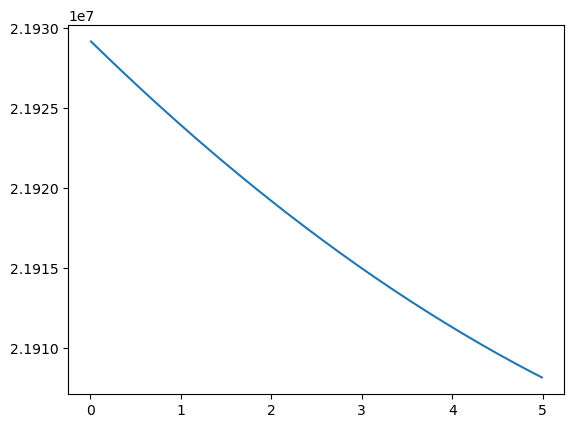

In [23]:
sns.lineplot(x=alpha,y=mse,markers='o')

In [ ]:
# Import LassoCV for cross-validated Lasso regression
from sklearn.linear_model import LassoCV
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
a1 = [x/100 for x in range(1, 500)]
lasso_cv_model = LassoCV(
    alphas=a1,  
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("best alpha: ", lasso_cv_model.alpha_)

best alpha:  0.01
